In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from scipy.stats import multivariate_normal
from scipy.spatial.distance import cdist

import pandas as pd
import gstools as gs

In [2]:
# Set all simu parameters 
# Set domain size and simulation time: this info is shared between the forward and parameter models 
Lx = 20
Lz = 1 
TEnd = 10 
H = 1.5

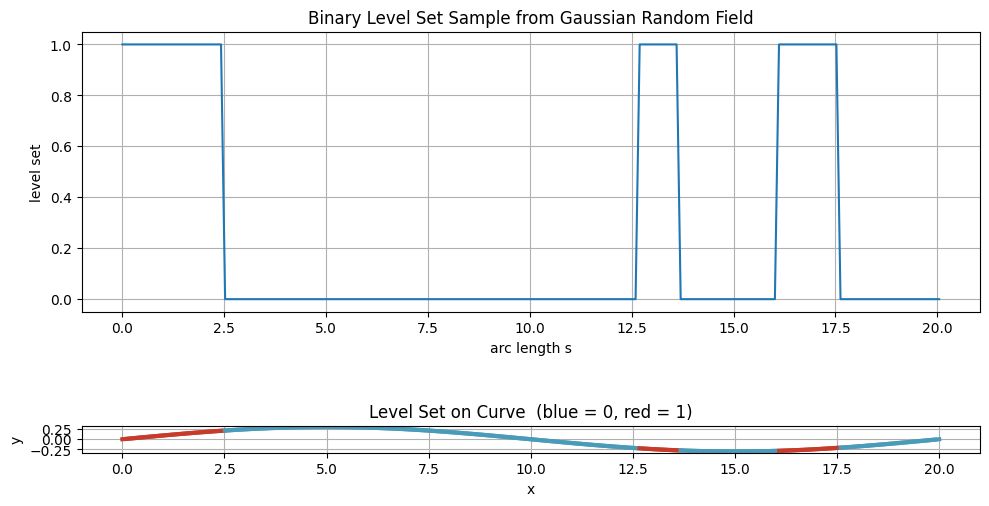

In [3]:
# Create level set of Gaussian random field
nx = 200

# Define manifold
t = np.linspace(0, 1, nx)
#curve = np.stack([t * Lx, np.zeros_like(t)], axis=1)
curve = np.stack([t * Lx, 0.3 * np.sin(2*np.pi*t)], axis=1)       # sine wave
# curve = np.stack([np.cos(2*np.pi*t), np.sin(2*np.pi*t), t], axis=1)  # helix

def arc_length_distances(curve):
    seg_lengths = np.linalg.norm(np.diff(curve, axis=0), axis=1)
    cumlen = np.concatenate([[0], np.cumsum(seg_lengths)])
    return np.abs(cumlen[:, None] - cumlen[None, :])

s = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(curve, axis=0), axis=1))])  # arc-length coordinate
D = arc_length_distances(curve)

def matern32_covariance(D, length_scale, variance=1.0):
    sqrt3 = np.sqrt(3.0)
    scaled = sqrt3 * D / length_scale
    return variance * (1.0 + scaled) * np.exp(-scaled)

def restriction(sampin, eps=1e-6):
    return (sampin > eps).astype(int)

total_arc_length = s[-1]
length_scale = 0.1 * total_arc_length

eps = 1e-6
cov = matern32_covariance(D, length_scale)
cov += eps * np.eye(nx)
mean = np.zeros(nx)

my_prior = multivariate_normal(mean=mean, cov=cov)
sample = my_prior.rvs()
binary = restriction(sample)


fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# Top: your original plot, x-axis is arc length s
ax = axes[0]
ax.grid()
ax.plot(s, binary)
ax.set_title("Binary Level Set Sample from Gaussian Random Field")
ax.set_xlabel("arc length s")
ax.set_ylabel("level set")

# Bottom: curve colored by binary field
ax2 = axes[1]
# plot segments colored by binary value
colors = {0: '#4a9aba', 1: '#c63b2a'}
for i in range(len(curve) - 1):
    seg = curve[i:i+2, :2]  # take first 2 dims for 2D plot
    ax2.plot(seg[:, 0], seg[:, 1], color=colors[binary[i]], linewidth=3)
ax2.set_aspect('equal')
ax2.grid()
ax2.set_title("Level Set on Curve  (blue = 0, red = 1)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

plt.tight_layout()
plt.show()

NameError: name 'x' is not defined

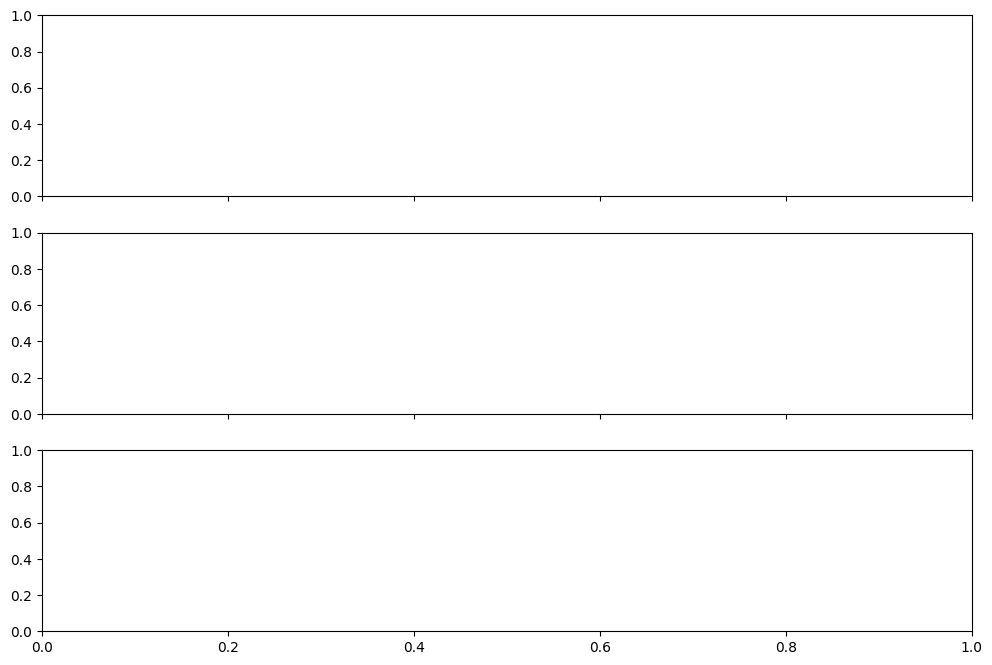

In [4]:
length_scales = [0.01 * Lx, 0.05 * Lx, 0.1 * Lx]  # fine → coarse

# --- Plot setup ---
fig, axes = plt.subplots(len(length_scales), 1, figsize=(12, 8), sharex=True)

for i, (ax, ell) in enumerate(zip(axes, length_scales)):
    if i == 2:
        # Create labeled artists (only once)
        ax.plot([], [], color="black", lw=1.2, label="Gaussian random field")
        ax.plot([], [], color="red", linestyle="--", lw=1, label="Threshold")
        ax2.step([], [], where="mid", color="blue", lw=1.8, label="Binary level set")
    
        # Combine legends from both axes
        lines_1, labels_1 = ax.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
    
        ax.legend(
            lines_1 + lines_2,
            labels_1 + labels_2,
            loc="lower right",
            fontsize=9
        )
    # GRF prior
    cov = matern32_covariance(x, ell)
    cov += 1e-8 * np.eye(nx)
    prior = multivariate_normal(mean=np.zeros(nx), cov=cov)

    # Sample
    raw_sample = prior.rvs()
    binary_sample = restriction(raw_sample)

    # --- Plot GRF ---
    ax.plot(x, raw_sample, color="black", lw=1.2)
    ax.axhline(eps, color="red", linestyle="--", lw=1)

    # Filled regions
    ax.fill_between(
        x.flatten(), raw_sample, eps,
        where=(raw_sample > eps),
        color="tab:blue", alpha=0.3
    )
    ax.fill_between(
        x.flatten(), raw_sample, eps,
        where=(raw_sample <= eps),
        color="lightgray", alpha=0.4
    )

    # --- Binary overlay ---
    ax2 = ax.twinx()
    ax2.step(
        x.flatten(),
        binary_sample,
        where="mid",
        color="blue",
        lw=1.8
    )
    ax2.set_ylim(-0.1, 1.1)
    ax2.set_yticks([0, 1])

    # Styling
    ax.set_ylabel("Field")
    ax.set_title(f"Length scale = {ell:.2f}")
    ax.grid(True, linestyle=":", alpha=0.5)

# Shared x-label
axes[-1].set_xlabel("x")

plt.tight_layout()

# --- Save ---
plt.savefig("binary_level_sets_comparison.png", dpi=300, bbox_inches="tight")

plt.show()